In [1]:
%cd /u/jcai1/code/usefulxai/code/my_method

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
from modules.mhim import MHIM
import cv2
import random
import seaborn as sns
import os

/scratch/bdem/jcai1/bdem_usefulxai/code/my_method


## 第一步：读取特征和 patch 坐标（来自 .h5）

In [3]:
# 第一步：读取特征和 patch 坐标（来自 .h5）
import h5py
import torch

def load_features_and_coords(h5_path):
    with h5py.File(h5_path, 'r') as f:
        features = torch.from_numpy(f['features'][:])  # shape: [N, D]
        coords_ = f['coords'][:]  # shape: [N, 2], each is [x, y]
    print(f"Loaded {features.shape[0]} patches, feature dim: {features.shape[1]}, coords shape: {coords_.shape}")
    return features, coords_

features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/tumor_001.h5")
# features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/normal_001.h5")

x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

print(f"X range: {x_min} → {x_max}")
print(f"Y range: {y_min} → {y_max}")

Loaded 36710 patches, feature dim: 1024, coords shape: (36710, 2)
X range: 704 → 90880
Y range: 10432 → 162304


In [5]:
print(coords[:10])


[[ 17856 153856]
 [ 17856 154112]
 [ 18112 153600]
 [ 18112 153856]
 [ 18112 154112]
 [ 18112 154368]
 [ 18368 153344]
 [ 18368 153600]
 [ 18368 153856]
 [ 18368 154112]]


## 第二步：读取已训练好模型的attention score

In [6]:
# Attention for TransMIL
pure = MHIM(da_act='relu',baseline='selfattn').eval()
pure.requires_grad_(False)

pure_cpt = torch.load('/u/jcai1/code/usefulxai/paper_results/pure_model/transmil_0507_1818/fold_0_model_best_auc.pt',map_location='cpu')

pure.load_state_dict(pure_cpt['model'], strict=False)
pure.eval()
with torch.no_grad():
    _, attns = pure.forward_test(features.unsqueeze(0),return_attn=True)
    attn = attns[-1].mean(dim=1).squeeze(0) # Take last layer
    print(attn.shape)
attn_scores = attn.cpu().numpy()
print(attn_scores)


torch.Size([36710])
[2.9557270e-07 2.9576299e-07 2.9455714e-07 ... 4.0359382e-07 1.7569596e-07
 3.6158352e-07]


In [7]:
# 得到每个坐标的attention
attn_norm = (attn_scores - attn_scores.min()) / (attn_scores.max() - attn_scores.min() + 1e-6)
coords_attn = {
    tuple(coords[i]): float(attn_norm[i]) for i in range(len(coords))
}
print(coords_attn)
for i, (x, y) in enumerate(coords[:5]):
    print(coords_attn[(x,y)])

{(17856, 153856): 0.14967550337314606, (17856, 154112): 0.14968188107013702, (18112, 153600): 0.1496415138244629, (18112, 153856): 0.14963622391223907, (18112, 154112): 0.1496213972568512, (18112, 154368): 0.1497427225112915, (18368, 153344): 0.1495998352766037, (18368, 153600): 0.14977382123470306, (18368, 153856): 0.1496177613735199, (18368, 154112): 0.14973559975624084, (18624, 151296): 0.1496025174856186, (18624, 151552): 0.1498887836933136, (18624, 151808): 0.14959871768951416, (18624, 153088): 0.14964936673641205, (18624, 153344): 0.14960907399654388, (18624, 153600): 0.14964011311531067, (18624, 153856): 0.1496272087097168, (18624, 154112): 0.14966361224651337, (18880, 151296): 0.14982695877552032, (18880, 151552): 0.14973044395446777, (18880, 151808): 0.14960376918315887, (18880, 152064): 0.14977072179317474, (18880, 152320): 0.1496242731809616, (18880, 152576): 0.1496354043483734, (18880, 152832): 0.14964048564434052, (18880, 153088): 0.14972332119941711, (18880, 153344): 0.14

In [10]:
import numpy as np

# Step 2: 计算前 5% 的阈值
top_percent = 0.5  # 如果你想保留 top 0.01%，就设为 0.0001
threshold = np.quantile(attn_norm, 1 - top_percent)

# Step 3: 提取 top 5% 的索引和对应 attention
top_indices = np.where(attn_norm >= threshold)[0]
top_attn = attn_norm[top_indices].astype(np.float32)

# Step 4: 对 top 5% 的 attention 再归一化到 [0,1]
top_attn_norm = (top_attn - top_attn.min()) / (top_attn.max() - top_attn.min())
print(len(top_attn_norm))
print("Top-attn norm max:", top_attn_norm.max())

# Step 5: 构建仅包含 top 5% 的 coords_attn 映射
coords_attn_topk = {
    tuple(coords[i]): float(top_attn_norm[j])
    for j, i in enumerate(top_indices)
}

print(len(coords_attn_topk))
# Step 6: 打印前 5 个 top patch 的坐标和 attention 值
for c, a in list(coords_attn_topk.items())[:10]:
    print(f"{c}: {a:.4f}")

coords_set = set(map(tuple, coords))

coords_attn_filtered = {
    (x, y): attn for (x, y), attn in coords_attn_topk.items()
    if (x, y) in coords_set and left <= x < right and top <= y < bottom
}
print(len(coords_attn_filtered))
attn_vals = np.array(list(coords_attn_filtered.values()), dtype=np.float32)
attn_vals_norm = (attn_vals - attn_vals.min()) / (attn_vals.max() - attn_vals.min())
coords_attn_region = {
    key: float(attn_vals_norm[i])
    for i, key in enumerate(coords_attn_filtered.keys())
}

for c, a in list(coords_attn_region.items())[:5]:
    print(f"{c}: {a:.4f}")

print(len(coords_attn_region))

temp = np.array(list(coords_attn_region.values()), dtype=np.float32)
temp = (temp - temp.min()) / (temp.max() - temp.min())

# Step 3: 构建新的归一化字典
coords_attn_region_norm = {
    key: float(temp[i])
    for i, key in enumerate(coords_attn_region.keys())
}

# ✅ 打印前几项检查
for c, a in list(coords_attn_region_norm.items())[:5]:
    print(f"{c}: {a:.4f}")

print(len(coords_attn_region))
print("Max attention value:", max(list(coords_attn_region_norm.values())))
print("Min attention value:", min(list(coords_attn_region_norm.values())))

18355
Top-attn norm max: 1.0
18355
(17856, 153856): 0.0002
(17856, 154112): 0.0002
(18112, 153600): 0.0002
(18112, 153856): 0.0002
(18112, 154112): 0.0002
(18112, 154368): 0.0003
(18368, 153344): 0.0001
(18368, 153600): 0.0003
(18368, 153856): 0.0001
(18368, 154112): 0.0003
972
(60224, 138880): 0.0504
(60480, 138624): 0.2203
(60480, 138880): 0.2017
(60736, 138624): 0.0251
(60736, 138880): 0.2321
972
(60224, 138880): 0.0504
(60480, 138624): 0.2203
(60480, 138880): 0.2017
(60736, 138624): 0.0251
(60736, 138880): 0.2321
972
Max attention value: 1.0
Min attention value: 0.0


## 第三步：根据mask文件得到绘制区间（level0）

In [11]:
from openslide import OpenSlide
import numpy as np

def get_tumor_region_from_mask(mask_path, mask_level=8):
    mask_slide = OpenSlide(mask_path)
    print("Level dimensions of mask:", mask_slide.level_dimensions)
    dims = mask_slide.level_dimensions[mask_level]
    mask_img = mask_slide.read_region((0, 0), mask_level, dims).convert("L")
    mask_arr = np.array(mask_img)
    
    mask_h, mask_w = mask_arr.shape
    x_range = (0, mask_w - 1)
    y_range = (0, mask_h - 1)
    print(f"Full X range of mask (level 8): {x_range}")
    print(f"Full Y range of mask (level 8): {y_range}")

    coords_ = np.argwhere(mask_arr == 2)
    if len(coords_) == 0:
        print("No tumor (label==2) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Tumor region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested tumor region (level 0):", region)
    
    coords_ = np.argwhere(mask_arr == 1)
    if len(coords_) == 0:
        print("No normal (label==1) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Normal region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested normal region (level 0):", region)
    
get_tumor_region_from_mask("/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif")

Level dimensions of mask: ((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864))
Full X range of mask (level 8): (0, 381)
Full Y range of mask (level 8): (0, 863)
Tumor region in mask level 8: x=[274, 286], y=[479, 525]
Suggested tumor region (level 0): (70144, 122624, 73216, 134400)
Normal region in mask level 8: x=[3, 351], y=[57, 826]
Suggested normal region (level 0): (768, 14592, 89856, 211456)


## 第四步：在原图上绘制attention和groud-truth annotation轮廓

In [12]:
svs_path="/u/jcai1/code/usefulxai/data/camelyon16/images/tumor_001.tif"
slide = OpenSlide(svs_path)
print(slide.level_dimensions)

((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864), (191, 432))


In [9]:
# region = (70144, 122624, 73472, 134656)  # 在 level=0 下的 region
region = (60144, 112624, 74216, 144400)
# region = (60144, 112624, 74216, 144400)
left, top, right, bottom = region
w, h = right - left, bottom - top

In [13]:
base_img = np.array(slide.read_region((left, top), 0, (w, h)).convert("RGB"))
print(base_img.shape)

(31776, 14072, 3)


In [16]:
mask_path="/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif"
mask_slide = OpenSlide(mask_path) 

In [17]:
mask_img = mask_slide.read_region((left, top), 8, (w, h)).convert("L")
mask_arr = np.array(mask_img)
print(mask_arr.shape)

(31776, 14072)


In [20]:
coords_set = set(map(tuple, coords))
# for (x, y) in coords_attn:
#     if (x, y) in coords_set:
#         print(f"({x}, {y}) exists in coords!")
for (x, y) in coords_set:
    if (x, y) in coords_attn:
        print(f"({x}, {y}) exists in coords!")

(56448, 124992) exists in coords!
(54080, 128128) exists in coords!
(52032, 138624) exists in coords!
(41152, 114880) exists in coords!
(48576, 77504) exists in coords!
(23744, 81856) exists in coords!
(50496, 138880) exists in coords!
(34752, 69568) exists in coords!
(36032, 151552) exists in coords!
(16320, 93376) exists in coords!
(26560, 112064) exists in coords!
(38592, 68800) exists in coords!
(20160, 92608) exists in coords!
(33216, 69824) exists in coords!
(31168, 80320) exists in coords!
(22976, 122816) exists in coords!
(29632, 80576) exists in coords!
(27584, 91072) exists in coords!
(40640, 68288) exists in coords!
(22208, 92096) exists in coords!
(50880, 86976) exists in coords!
(69760, 122176) exists in coords!
(26048, 91328) exists in coords!
(5568, 125632) exists in coords!
(39104, 68544) exists in coords!
(37056, 79040) exists in coords!
(66176, 132928) exists in coords!
(12224, 83392) exists in coords!
(31680, 80064) exists in coords!
(39872, 109248) exists in coords!

[INFO] Attn min: 0.0 max: 0.96653026 attn_norm shape (36710,)
73088 124480
61312 113216
74112 124480
62592 116544
73856 124224
73344 124480
73088 130880
73600 123968
60288 112960
73088 124224
62272 139392
72832 123968
62016 139136
73856 123968
60544 112960
61568 112960
73600 130368
74112 130112
62272 139136
71808 123712
73856 123200
73856 130368
73344 130624
73856 123712
60544 112704
73600 130112
74112 129856
73088 123712
72576 123968
61760 139136
71808 123456
73856 122944
73856 130112
72832 123456
73344 130368
72320 123712
66432 118336
73600 129856
74112 129600
72064 123456
74112 122944
73856 129344
60736 138880
72576 123712
71808 123200
73856 122688
72320 130112
73600 129088
60480 138624
72320 123456
73600 122432
71040 126016
74112 129344
72064 123200
74112 122688
72576 123456
71808 122944
73856 122432
71296 126016
72320 123200
73600 122176
71040 125760
60480 138880
72064 122944
74112 122432
72576 122688
71552 126016
72576 123200
71808 122688
73856 122176
71296 125760
70016 120128
72

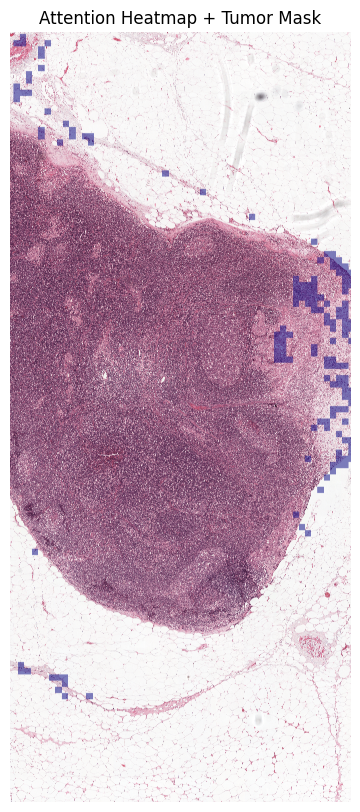

In [37]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(_base_img, coords_, coords_attn_, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             _mask_arr=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------
    coords_set = set(map(tuple, coords_))

    heatmap = _base_img.copy()

    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max(),"attn_norm shape",attn_norm.shape)
    
    for (x, y) in coords_set:
        if (x, y) in coords_attn_:
    # for i, (x, y) in enumerate(coords_): # x,x+256,y,y+256对应原图在level0的一个小方块
            x = int(x)
            y=int(y)
            # print(x,y) # 56960 113280 ; 56960 113536
            if not (left <= x < right and top <= y < bottom):
                continue  # skip patches outside region
            print(x,y)
            rel_x = int(x - left)
            rel_y = int(y - top)
            # print("pt1", (rel_x, rel_y), "pt2", (rel_x + 256, rel_y + 256))
            # pt1 (144, 400) pt2 (400, 656)
            # pt1 (13968, 7568) pt2 (14224, 7824)
            color = plt.cm.jet(coords_attn_[(x,y)])[:3]
            color = tuple(int(255 * c) for c in color)
            # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
            cv2.rectangle(
                img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                pt1=(rel_x, rel_y),                   # 左上角坐标
                pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
                color=color,                          # 矩形颜色（B, G, R）格式
                thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
            )
    print("aaa")
        # * -------------- 加载mask并绘制轮廓 --------------
        # if _mask_arr is not None:
            
        #     print(f"[INFO] Partial mask shape: {_mask_arr.shape}, unique labels: {np.unique(_mask_arr)}")
            
        #     # 提取 tumor 区域并绘制边界（仅 label==2）
        #     tumor_mask = (_mask_arr == 2).astype(np.uint8)
        #     count = np.sum(tumor_mask == 1) # tumor的mask只存在于图片左上角
        #     temp = np.argwhere(tumor_mask == 1)
        #     print(f"Found {len(temp)} coordinates with value 1:")
        #     for t in temp:
        #         rel_x, rel_y = t[0]*256, t[1]*256

        #         color =  (0, 0, 255) # 绿色
        #         # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
        #         cv2.rectangle(
        #             img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
        #             pt1=(rel_x, rel_y),                   # 左上角坐标
        #             pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
        #             color=color,                          # 矩形颜色（B, G, R）格式
        #             thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
        #         )
            
    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

                
    # ------------------------------------------------

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    

# show_attention_on_region(
#     _base_img=base_img,
#     coords_=coords,
#     coords_attn_=coords_attn,
#     _mask_arr=mask_arr)

show_attention_on_region(
    _base_img=base_img,
    coords_=coords,
    coords_attn_=coords_attn_topk,
    _mask_arr=mask_arr)


[INFO] Attn min: 0.0 max: 0.96653026 attn_norm shape (36710,)
aaa


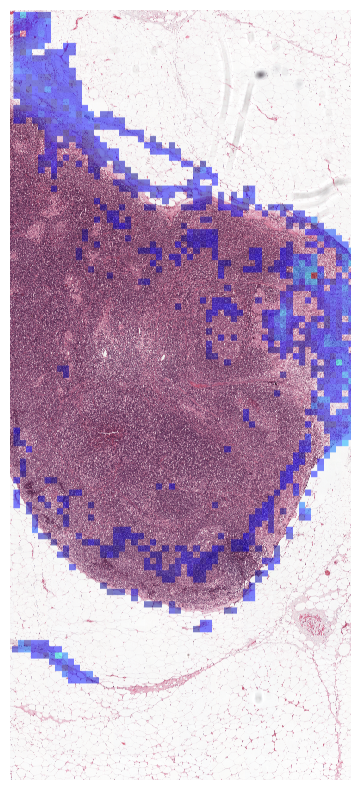

In [18]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(_base_img, coords_, coords_attn_, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             _mask_arr=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------
    coords_set = set(map(tuple, coords_))

    heatmap = _base_img.copy()

    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max(),"attn_norm shape",attn_norm.shape)
    
    for (x, y) in coords_set:
        if (x, y) in coords_attn_:
    # for i, (x, y) in enumerate(coords_): # x,x+256,y,y+256对应原图在level0的一个小方块
            x = int(x)
            y=int(y)
            # print(x,y) # 56960 113280 ; 56960 113536
            if not (left <= x < right and top <= y < bottom):
                continue  # skip patches outside region
            rel_x = int(x - left)
            rel_y = int(y - top)
            # print("pt1", (rel_x, rel_y), "pt2", (rel_x + 256, rel_y + 256))
            # pt1 (144, 400) pt2 (400, 656)
            # pt1 (13968, 7568) pt2 (14224, 7824)
            color = plt.cm.jet(coords_attn_[(x,y)])[:3]
            color = tuple(int(255 * c) for c in color)
            # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
            cv2.rectangle(
                img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                pt1=(rel_x, rel_y),                   # 左上角坐标
                pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
                color=color,                          # 矩形颜色（B, G, R）格式
                thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
            )
    print("aaa")
        # * -------------- 加载mask并绘制轮廓 --------------
        # if _mask_arr is not None:
            
        #     print(f"[INFO] Partial mask shape: {_mask_arr.shape}, unique labels: {np.unique(_mask_arr)}")
            
        #     # 提取 tumor 区域并绘制边界（仅 label==2）
        #     tumor_mask = (_mask_arr == 2).astype(np.uint8)
        #     count = np.sum(tumor_mask == 1) # tumor的mask只存在于图片左上角
        #     temp = np.argwhere(tumor_mask == 1)
        #     print(f"Found {len(temp)} coordinates with value 1:")
        #     for t in temp:
        #         rel_x, rel_y = t[0]*256, t[1]*256

        #         color =  (0, 0, 255) # 绿色
        #         # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
        #         cv2.rectangle(
        #             img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
        #             pt1=(rel_x, rel_y),                   # 左上角坐标
        #             pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
        #             color=color,                          # 矩形颜色（B, G, R）格式
        #             thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
        #         )
            
    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

                
    # ------------------------------------------------

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    # plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    

# show_attention_on_region(
#     _base_img=base_img,
#     coords_=coords,
#     coords_attn_=coords_attn,
#     _mask_arr=mask_arr)

show_attention_on_region(
    _base_img=base_img,
    coords_=coords,
    coords_attn_=coords_attn_region_norm,
    _mask_arr=mask_arr)
